In [35]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import random
from collections import deque
import tkinter as tk
import time
import requests
import base64
import signal

In [36]:
API_KEY = 'W8JCC52R'
BASE_URL = 'http://141.211.79.101:10002/v1'
USERNAME = 'user4'
PASSWORD = 'user4'


AUTHORIZATION = {
    'Authorization': 'Basic ' + base64.b64encode(f"{USERNAME}:{PASSWORD}".encode()).decode()
}

class RITGateway:
    def __init__(self, username, password, host='http://141.211.79.101:10002', use_http=True):
        protocol = 'http' if use_http else 'https'
        self.base_url = f'{protocol}://{host.split("://")[-1]}/v1'
        self.session = requests.Session()

        auth_value = base64.b64encode(f'{username}:{password}'.encode()).decode()
        self.session.headers.update({
            'Authorization': f'Basic {auth_value}'
        })

    def _request(self, method, endpoint, params=None):
        url = f'{self.base_url}/{endpoint}'

        while True:
            if method == 'GET':
                resp = self.session.get(url, params=params)
            elif method == 'POST':
                resp = self.session.post(url, params=params)
            elif method == 'DELETE':
                resp = self.session.delete(url, params=params)
            else:
                raise ValueError(f'Unsupported HTTP method: {method}')

            if resp.status_code == 401:
                raise ApiException('Authentication failed. Check username/password.')

            if resp.status_code == 429:
                wait_time = float(resp.headers.get('Retry-After', 1))
                print(f'Rate limit hit. Sleeping {wait_time} sec.')
                time.sleep(wait_time)
                continue

            if not resp.ok:
                raise ApiException(f'API request failed: {resp.status_code} {resp.text}')

            if resp.text.strip():
                return resp.json()
            return None

    def get_case(self):
        return self._request('GET', 'case')

    def get_securities(self):
        return self._request('GET', 'securities')

    def get_security(self, ticker):
        securities = self.get_securities()
        for sec in securities:
            if sec.get('ticker') == ticker:
                return sec
        return None

    def get_book(self, ticker):
        return self._request('GET', 'securities/book', params={'ticker': ticker})

    def get_orders(self, status=None):
        params = {}
        if status is not None:
            params['status'] = status
        return self._request('GET', 'orders', params=params)

    def submit_order(self, ticker, order_type, quantity, action, price=None):
        params = {
            'ticker': ticker,
            'type': order_type,
            'quantity': int(quantity),
            'action': action
        }
        if price is not None:
            params['price'] = round(float(price), 2)

        return self._request('POST', 'orders', params=params)

    def cancel_all_orders(self):
        return self._request('POST', 'commands/cancel', params={'all': 1})

    def cancel_order(self, order_id):
        return self._request('DELETE', f'orders/{order_id}')

In [37]:
class Quoter:
    def __init__(
        self,
        quote_width=0.10,
        base_size=600,
        position_limit=10000,
        max_skew_cents=0.04
    ):
        self.quote_width = quote_width
        self.base_size = base_size
        self.position_limit = position_limit
        self.max_skew_cents = max_skew_cents

    def compute_quotes(self, best_bid, best_ask, inventory):
        base = self.base_size
        mid = (best_bid + best_ask) / 2

        inv_ratio = max(-1.0, min(1.0, inventory / self.position_limit))
        abs_ratio = abs(inv_ratio)

        # inventory-based skew: positive inventory shifts quotes lower, negative higher
        skew = np.sign(inv_ratio) * (abs_ratio ** 1.5) * self.max_skew_cents * 1.25

        # keep width competitive when near flat, widen modestly when loaded
        if abs(inventory) < 1000:
            dynamic_width = max(self.quote_width, best_ask - best_bid)
        else:
            dynamic_width = self.quote_width * (1.0 + 0.5 * abs_ratio)

        half_width = dynamic_width / 2

        bid_price = round(mid - half_width - skew, 2)
        ask_price = round(mid + half_width - skew, 2)

        # when near flat, stay competitive with the market
        if abs(inventory) < 1000:
            bid_price = min(max(bid_price, best_bid), best_ask - 0.01)
            ask_price = max(min(ask_price, best_ask), best_bid + 0.01)

        # never cross yourself
        if bid_price >= ask_price:
            bid_price = round(ask_price - 0.01, 2)

        # inventory-aware sizing
        if inventory > 0:
            bid_mult = max(0.0, 0.5 - 1.5 * abs_ratio)
            ask_mult = min(2.5, 1.0 + 1.2 * abs_ratio)
        elif inventory < 0:
            bid_mult = min(2.5, 1.0 + 1.2 * abs_ratio)
            ask_mult = max(0.0, 0.5 - 1.5 * abs_ratio)
        else:
            bid_mult = 1.0
            ask_mult = 1.0

        # hard shutoff of the wrong side when inventory is too large
        if inventory >= 2500:
            bid_mult = 0.0
        elif inventory <= -2500:
            ask_mult = 0.0

        bid_size = max(0, int(round(base * bid_mult / 100.0)) * 100)
        ask_size = max(0, int(round(base * ask_mult / 100.0)) * 100)

        return {
            'bid_price': bid_price,
            'ask_price': ask_price,
            'bid_size': bid_size,
            'ask_size': ask_size
        }

In [38]:
class Lifter:
    def __init__(self, max_clip=3000):
        self.max_clip = max_clip

    def lift_ask(self, best_ask, inventory):
        qty = min(self.max_clip, abs(int(inventory)))
        qty = max(100, int(qty / 100) * 100)
        return {
            'action': 'BUY',
            'quantity': qty,
            'price': best_ask
        }

In [39]:
class Hitter:
    def __init__(self, max_clip=3000):
        self.max_clip = max_clip

    def hit_bid(self, best_bid, inventory):
        qty = min(self.max_clip, abs(int(inventory)))
        qty = max(100, int(qty / 100) * 100)
        return {
            'action': 'SELL',
            'quantity': qty,
            'price': best_bid
        }


In [40]:

class TraderUI:
    def __init__(self):
        if tk._default_root is not None:
            try:
                tk._default_root.destroy()
            except Exception:
                pass

        self.root = tk.Tk()
        self.root.title('LT1 Dashboard')
        self.root.geometry('560x430')
        self.root.configure(bg='#111111')
        self.root.resizable(False, False)

        self.flash_on = False
        self.alert_active = False
        self.flash_job = None
        self.flash_color_1 = 'red'
        self.flash_color_2 = 'black'

        self.gateway = None
        self.stop_requested = False

        title = tk.Label(
            self.root,
            text='LT1 TRADER DASHBOARD',
            font=('Helvetica', 17, 'bold'),
            fg='white',
            bg='#111111'
        )
        title.pack(pady=10)

        self.position_label = self.make_label('Position: 0')
        self.pnl_label = self.make_label('PnL: 0.00')
        self.regime_label = self.make_label('Regime: NORMAL')
        self.mode_label = self.make_label('Mode: Quoting')
        self.market_label = self.make_label('Market: - / -')
        self.quote_label = self.make_label('Quote: - / -')
        self.unusual_label = self.make_label('Unusual Flow: NO')
        self.toxic_label = self.make_label('Toxic Flow: NO')

        self.alert_box = tk.Label(
            self.root,
            text='MARKET STATUS: NORMAL',
            font=('Helvetica', 14, 'bold'),
            fg='white',
            bg='dark green',
            width=30,
            height=2
        )
        self.alert_box.pack(pady=16)

        button_frame = tk.Frame(self.root, bg='#111111')
        button_frame.pack(pady=8)

        self.kill_button = tk.Button(
            button_frame,
            text='KILL ALL ORDERS',
            font=('Helvetica', 12, 'bold'),
            bg='firebrick',
            fg='white',
            width=18,
            command=self.kill_all_orders
        )
        self.kill_button.grid(row=0, column=0, padx=8)

        self.stop_button = tk.Button(
            button_frame,
            text='STOP LOOP',
            font=('Helvetica', 12, 'bold'),
            bg='gray25',
            fg='white',
            width=12,
            command=self.request_stop
        )
        self.stop_button.grid(row=0, column=1, padx=8)

    def set_gateway(self, gateway):
        self.gateway = gateway

    def request_stop(self):
        self.stop_requested = True
        self.alert_box.config(text='STOP REQUESTED', bg='gray25', fg='white')

    def kill_all_orders(self):
        if self.gateway is None:
            self.alert_box.config(text='NO GATEWAY SET', bg='orange', fg='black')
            return
        try:
            self.gateway.cancel_all_orders()
            self.alert_box.config(text='ALL ORDERS CANCELLED', bg='purple', fg='white')
        except Exception as e:
            self.alert_box.config(text=f'KILL FAILED: {str(e)[:25]}', bg='red', fg='white')

    def make_label(self, text):
        label = tk.Label(
            self.root,
            text=text,
            font=('Helvetica', 12),
            fg='white',
            bg='#111111',
            anchor='w'
        )
        label.pack(fill='x', padx=20, pady=3)
        return label

    def update(
        self,
        inventory,
        pnl,
        regime,
        mode,
        best_bid,
        best_ask,
        order,
        unusual_activity=False,
        toxic_flow=False
    ):
        self.position_label.config(text=f'Position: {inventory}')
        self.pnl_label.config(text=f'PnL: {pnl:.2f}')
        self.regime_label.config(text=f'Regime: {regime}')
        self.mode_label.config(text=f'Mode: {mode}')
        self.market_label.config(text=f'Market: {best_bid:.2f} / {best_ask:.2f}')

        if mode == 'Quoting' and order is not None:
            self.quote_label.config(
                text=f"Quote: {order.get('bid_price', '-')} x {order.get('bid_size', '-')}  /  {order.get('ask_price', '-')} x {order.get('ask_size', '-')}"
            )
        elif order is not None:
            self.quote_label.config(
                text=f"Order: {order.get('action', '-')} {order.get('quantity', '-')} @ {order.get('price', '-')}"
            )
        else:
            self.quote_label.config(text='Quote: - / -')

        self.unusual_label.config(text=f"Unusual Flow: {'YES' if unusual_activity else 'NO'}")
        self.toxic_label.config(text=f"Toxic Flow: {'YES' if toxic_flow else 'NO'}")

        if toxic_flow:
            self.set_alert('TOXIC FLOW DETECTED', 'red', 'black')
        elif unusual_activity:
            self.set_alert('UNUSUAL FLOW DETECTED', 'orange', 'black')
        else:
            self.clear_alert()

        try:
            self.root.update_idletasks()
            self.root.update()
        except:
            pass

    def set_alert(self, text, color1, color2):
        self.alert_box.config(text=text)
        self.flash_color_1 = color1
        self.flash_color_2 = color2

        if not self.alert_active:
            self.alert_active = True
            self.flash()

    def flash(self):
        if not self.alert_active:
            return

        self.flash_on = not self.flash_on
        bg = self.flash_color_1 if self.flash_on else self.flash_color_2
        fg = 'white' if self.flash_on else 'yellow'
        self.alert_box.config(bg=bg, fg=fg)

        self.flash_job = self.root.after(300, self.flash)

    def clear_alert(self):
        if self.alert_active:
            self.alert_active = False
            self.flash_on = False
            if self.flash_job is not None:
                self.root.after_cancel(self.flash_job)
                self.flash_job = None

        if not self.stop_requested:
            self.alert_box.config(
                text='MARKET STATUS: NORMAL',
                bg='dark green',
                fg='white'
            )

In [41]:

class MarketMonitor:
    def __init__(
        self,
        max_history=30,
        large_order_threshold=5000,
        streak_len=3,
        wide_spread_threshold=0.12,
        one_sided_flow_len=3
    ):
        self.max_history = max_history
        self.large_order_threshold = large_order_threshold
        self.streak_len = streak_len
        self.wide_spread_threshold = wide_spread_threshold
        self.one_sided_flow_len = one_sided_flow_len

        self.recent_sides = deque(maxlen=max_history)
        self.recent_qtys = deque(maxlen=max_history)
        self.recent_types = deque(maxlen=max_history)
        self.recent_spreads = deque(maxlen=max_history)

    def record_order(self, incoming_side, incoming_qty, incoming_type):
        if incoming_side is not None:
            self.recent_sides.append(incoming_side)
        if incoming_qty is not None:
            self.recent_qtys.append(incoming_qty)
        if incoming_type is not None:
            self.recent_types.append(incoming_type)

    def record_spread(self, best_bid, best_ask):
        spread = round(best_ask - best_bid, 4)
        self.recent_spreads.append(spread)

    def detect_large_order(self, incoming_qty=None):
        if incoming_qty is not None:
            return incoming_qty >= self.large_order_threshold
        if len(self.recent_qtys) == 0:
            return False
        return self.recent_qtys[-1] >= self.large_order_threshold

    def detect_market_order_streak(self, streak_len=None):
        if streak_len is None:
            streak_len = self.streak_len
        if len(self.recent_types) < streak_len:
            return False
        last_types = list(self.recent_types)[-streak_len:]
        return all(t == 'MARKET' for t in last_types)

    def detect_wide_spread(self, best_bid=None, best_ask=None, threshold=None):
        if threshold is None:
            threshold = self.wide_spread_threshold

        if best_bid is not None and best_ask is not None:
            spread = best_ask - best_bid
            self.recent_spreads.append(spread)
            return spread >= threshold

        if len(self.recent_spreads) == 0:
            return False

        return self.recent_spreads[-1] >= threshold

    def detect_one_sided_flow(self, streak_len=None):
        if streak_len is None:
            streak_len = self.one_sided_flow_len
        if len(self.recent_sides) < streak_len:
            return False
        last_sides = list(self.recent_sides)[-streak_len:]
        return all(s == 'BUY' for s in last_sides) or all(s == 'SELL' for s in last_sides)

    def reset(self):
        self.recent_sides.clear()
        self.recent_qtys.clear()
        self.recent_types.clear()
        self.recent_spreads.clear()

In [42]:
class Trader:
    def __init__(
        self,
        quoter,
        hitter,
        lifter,
        monitor,
        position_limit=10000,
        caution_limit=5000,
        emergency_limit=9000,
        momentum_window=3,
        aggressive_size=500,
        aggressive_inventory_cap=2000,
        min_aggressive_edge=0.02,
        endgame_start=270,
        hard_flatten_start=285,
        final_flatten_start=295
    ):
        self.quoter = quoter
        self.hitter = hitter
        self.lifter = lifter
        self.monitor = monitor

        self.position_limit = position_limit
        self.caution_limit = caution_limit
        self.emergency_limit = emergency_limit

        self.momentum_window = momentum_window
        self.aggressive_size = aggressive_size
        self.aggressive_inventory_cap = aggressive_inventory_cap
        self.min_aggressive_edge = min_aggressive_edge

        self.endgame_start = endgame_start
        self.hard_flatten_start = hard_flatten_start
        self.final_flatten_start = final_flatten_start

        self.mid_history = deque(maxlen=momentum_window)

    def get_regime(self, inventory):
        abs_inv = abs(inventory)
        if abs_inv >= self.emergency_limit:
            return 'EMERGENCY'
        elif abs_inv >= self.caution_limit:
            return 'CAUTION'
        return 'NORMAL'

    def should_hit(self, inventory):
        return inventory >= self.emergency_limit

    def should_lift(self, inventory):
        return inventory <= -self.emergency_limit

    def update_mid_history(self, best_bid, best_ask):
        mid = (best_bid + best_ask) / 2
        self.mid_history.append(mid)
        return mid

    def get_momentum_signal(self):
        if len(self.mid_history) < self.momentum_window:
            return 0

        mids = list(self.mid_history)

        if all(mids[i] < mids[i + 1] for i in range(len(mids) - 1)):
            return 1

        if all(mids[i] > mids[i + 1] for i in range(len(mids) - 1)):
            return -1

        return 0

    def detect_unusual(
        self,
        best_bid,
        best_ask,
        incoming_side=None,
        incoming_qty=None,
        incoming_type=None
    ):
        if incoming_side is not None or incoming_qty is not None or incoming_type is not None:
            self.monitor.record_order(incoming_side, incoming_qty, incoming_type)

        flags = {
            'large_order': self.monitor.detect_large_order(incoming_qty) if incoming_qty is not None else False,
            'market_order_streak': self.monitor.detect_market_order_streak() if incoming_type is not None else False,
            'wide_spread': self.monitor.detect_wide_spread(best_bid, best_ask),
            'one_sided_flow': self.monitor.detect_one_sided_flow() if incoming_side is not None else False
        }

        flags['unusual_activity'] = any(flags.values())
        return flags

    def make_aggressive_buy_order(self, best_ask, inventory, size=None):
        if size is None:
            size = self.aggressive_size

        qty = min(size, self.position_limit - inventory)
        qty = max(0, int(qty / 100) * 100)

        if qty < 100:
            return None

        return {
            'action': 'BUY',
            'quantity': qty,
            'price': best_ask
        }

    def make_aggressive_sell_order(self, best_bid, inventory, size=None):
        if size is None:
            size = self.aggressive_size

        qty = min(size, self.position_limit + inventory)
        qty = max(0, int(qty / 100) * 100)

        if qty < 100:
            return None

        return {
            'action': 'SELL',
            'quantity': qty,
            'price': best_bid
        }

    def should_aggress_buy(self, best_bid, best_ask, inventory, momentum_signal):
        if abs(inventory) >= self.aggressive_inventory_cap:
            return False

        if inventory > 0:
            return False

        if momentum_signal != 1:
            return False

        return True


    def should_aggress_sell(self, best_bid, best_ask, inventory, momentum_signal):
        if abs(inventory) >= self.aggressive_inventory_cap:
            return False

        if inventory < 0:
            return False

        if momentum_signal != -1:
            return False

        return True

    def should_endgame_flatten(self, tick, inventory):
        if tick is None:
            return False

        abs_inv = abs(inventory)

        if tick >= self.final_flatten_start and abs_inv > 0:
            return True
        if tick >= self.hard_flatten_start and abs_inv > 500:
            return True
        if tick >= self.endgame_start and abs_inv > 1500:
            return True

        return False

    def decide_action(
        self,
        best_bid,
        best_ask,
        inventory,
        tick=None,
        incoming_side=None,
        incoming_qty=None,
        incoming_type=None
    ):
        regime = self.get_regime(inventory)
        self.update_mid_history(best_bid, best_ask)
        momentum_signal = self.get_momentum_signal()

        flags = self.detect_unusual(
            best_bid,
            best_ask,
            incoming_side,
            incoming_qty,
            incoming_type
        )

        unusual = flags['unusual_activity']
        toxic = flags['market_order_streak'] or flags['one_sided_flow']

        # Emergency flatten
        if self.should_hit(inventory):
            order = self.hitter.hit_bid(best_bid, inventory)
            return {
                'mode': 'Aggressive Sell',
                'regime': regime,
                'unusual_activity': unusual,
                'toxic_flow': toxic,
                'flags': flags,
                'order': order
            }

        if self.should_lift(inventory):
            order = self.lifter.lift_ask(best_ask, inventory)
            return {
                'mode': 'Aggressive Buy',
                'regime': regime,
                'unusual_activity': unusual,
                'toxic_flow': toxic,
                'flags': flags,
                'order': order
            }

        # Endgame flatten
        if self.should_endgame_flatten(tick, inventory):
            if inventory > 0:
                order = self.make_aggressive_sell_order(
                    best_bid,
                    inventory,
                    size=min(2000, abs(inventory))
                )
                return {
                    'mode': 'Aggressive Sell',
                    'regime': regime,
                    'unusual_activity': unusual,
                    'toxic_flow': toxic,
                    'flags': flags,
                    'order': order
                }

            elif inventory < 0:
                order = self.make_aggressive_buy_order(
                    best_ask,
                    inventory,
                    size=min(2000, abs(inventory))
                )
                return {
                    'mode': 'Aggressive Buy',
                    'regime': regime,
                    'unusual_activity': unusual,
                    'toxic_flow': toxic,
                    'flags': flags,
                    'order': order
                }

        # Opportunistic aggression
        if not unusual:
            if self.should_aggress_buy(best_bid, best_ask, inventory, momentum_signal):
                order = self.make_aggressive_buy_order(best_ask, inventory)
                if order is not None:
                    return {
                        'mode': 'Aggressive Buy',
                        'regime': regime,
                        'unusual_activity': unusual,
                        'toxic_flow': toxic,
                        'flags': flags,
                        'order': order
                    }

            if self.should_aggress_sell(best_bid, best_ask, inventory, momentum_signal):
                order = self.make_aggressive_sell_order(best_bid, inventory)
                if order is not None:
                    return {
                        'mode': 'Aggressive Sell',
                        'regime': regime,
                        'unusual_activity': unusual,
                        'toxic_flow': toxic,
                        'flags': flags,
                        'order': order
                    }

        # Normal quoting
        quotes = self.quoter.compute_quotes(best_bid, best_ask, inventory)

        # One-sided / defensive quoting when inventory is meaningful
        if abs(inventory) >= 4000:
            if inventory > 0:
                quotes['bid_size'] = 100
                quotes['ask_size'] = max(500, quotes['ask_size'])
                quotes['bid_price'] = round(quotes['bid_price'] - 0.03, 2)
            else:
                quotes['ask_size'] = 100
                quotes['bid_size'] = max(500, quotes['bid_size'])
                quotes['ask_price'] = round(quotes['ask_price'] + 0.03, 2)

        # More defensive during unusual conditions
        if unusual:
            quotes['bid_size'] = max(100, int((quotes['bid_size'] * 0.5) / 100) * 100)
            quotes['ask_size'] = max(100, int((quotes['ask_size'] * 0.5) / 100) * 100)
            quotes['bid_price'] = round(quotes['bid_price'] - 0.01, 2)
            quotes['ask_price'] = round(quotes['ask_price'] + 0.01, 2)

        if quotes['bid_price'] >= quotes['ask_price']:
            quotes['bid_price'] = round(quotes['ask_price'] - 0.01, 2)

        return {
            'mode': 'Quoting',
            'regime': regime,
            'unusual_activity': unusual,
            'toxic_flow': toxic,
            'flags': flags,
            'order': quotes
        }

    def step(
        self,
        best_bid,
        best_ask,
        inventory,
        tick=None,
        incoming_side=None,
        incoming_qty=None,
        incoming_type=None
    ):
        return self.decide_action(
            best_bid,
            best_ask,
            inventory,
            tick,
            incoming_side,
            incoming_qty,
            incoming_type
        )

In [43]:
# Help functions
def get_best_bid_ask(book):
    bids = book.get('bids', [])
    asks = book.get('asks', [])

    best_bid = float(bids[0]['price']) if bids else None
    best_ask = float(asks[0]['price']) if asks else None

    return best_bid, best_ask


def estimate_pnl_from_security(sec, mid_price):
    if sec is None:
        return 0.0

    if 'realized' in sec and 'unrealized' in sec:
        try:
            return float(sec['realized']) + float(sec['unrealized'])
        except Exception:
            pass

    position = float(sec.get('position', 0))
    return position * mid_price


# Signal handler for graceful shutdown
shutdown = False


def signal_handler(signum, frame):
    global shutdown
    signal.signal(signal.SIGINT, signal.SIG_DFL)
    shutdown = True


In [44]:
# Trade analysis
def log_loop(loop_log, tick, best_bid, best_ask, inventory, pnl, decision):
    order = decision.get('order')
    mode = decision.get('mode')

    row = {
        'tick': tick,
        'best_bid': best_bid,
        'best_ask': best_ask,
        'mid': (best_bid + best_ask) / 2,
        'spread': best_ask - best_bid,
        'inventory': inventory,
        'pnl': pnl,
        'mode': mode,
        'regime': decision.get('regime'),
        'unusual_activity': decision.get('unusual_activity', False),
        'toxic_flow': decision.get('toxic_flow', False),
        'quoted_bid': None,
        'quoted_ask': None,
        'quoted_bid_size': None,
        'quoted_ask_size': None,
        'aggressive_action': None,
        'aggressive_qty': None,
        'aggressive_price': None
    }

    if order is not None:
        if mode == 'Quoting':
            row['quoted_bid'] = order.get('bid_price')
            row['quoted_ask'] = order.get('ask_price')
            row['quoted_bid_size'] = order.get('bid_size')
            row['quoted_ask_size'] = order.get('ask_size')
        else:
            row['aggressive_action'] = order.get('action')
            row['aggressive_qty'] = order.get('quantity')
            row['aggressive_price'] = order.get('price')

    loop_log.append(row)


def log_order(order_log, tick, ticker, event_type, mode, order_type, action, quantity, price, inventory_before):
    order_log.append({
        'tick': tick,
        'ticker': ticker,
        'event_type': event_type,   # 'submit' or 'cancel_all'
        'mode': mode,
        'order_type': order_type,   # LIMIT / MARKET / None
        'action': action,           # BUY / SELL / None
        'quantity': quantity,
        'price': price,
        'inventory_before': inventory_before
    })


def infer_and_log_fills(fill_log, tick, prev_inventory, inventory, best_bid, best_ask, prev_mid, mode):
    delta = inventory - prev_inventory
    if delta == 0:
        return

    side = 'BUY' if delta > 0 else 'SELL'
    qty = abs(delta)

    # crude fill-price estimate:
    # if inventory increased, assume bought near previous bid/ask depending on mode
    if side == 'BUY':
        est_price = best_ask if mode == 'Aggressive Buy' else best_bid
        edge_vs_mid = prev_mid - est_price
    else:
        est_price = best_bid if mode == 'Aggressive Sell' else best_ask
        edge_vs_mid = est_price - prev_mid

    fill_log.append({
        'tick': tick,
        'side': side,
        'qty': qty,
        'inventory_before': prev_inventory,
        'inventory_after': inventory,
        'estimated_fill_price': est_price,
        'mid_before': prev_mid,
        'edge_per_share': edge_vs_mid,
        'estimated_edge_dollars': edge_vs_mid * qty,
        'mode': mode
    })

In [45]:
def run_live_trader_logged(gateway, trader, ui, ticker='HAR', poll_delay=0.4):
    ui.set_gateway(gateway)

    loop_log = []
    order_log = []
    fill_log = []

    last_quote = None
    last_action_time = 0

    prev_inventory = None
    prev_mid = None
    prev_mode = None

    while True:
        try:
            if ui.stop_requested:
                print('Stop requested from UI.')
                try:
                    gateway.cancel_all_orders()
                    log_order(order_log, None, ticker, 'cancel_all', None, None, None, None, None, None)
                except Exception:
                    pass
                break

            case_data = gateway.get_case()
            tick = case_data.get('tick')
            status = case_data.get('status')

            if status != 'ACTIVE':
                print('Case not active.')
                break

            book = gateway.get_book(ticker)
            best_bid, best_ask = get_best_bid_ask(book)

            if best_bid is None or best_ask is None:
                time.sleep(poll_delay)
                continue

            sec = gateway.get_security(ticker)
            inventory = int(float(sec.get('position', 0))) if sec else 0
            mid_price = (best_bid + best_ask) / 2
            pnl = estimate_pnl_from_security(sec, mid_price)

            decision = trader.step(
                best_bid=best_bid,
                best_ask=best_ask,
                inventory=inventory,
                tick=tick
            )

            mode = decision['mode']
            order = decision['order']

            # infer fills from position changes
            if prev_inventory is not None and prev_mid is not None and prev_mode is not None:
                infer_and_log_fills(
                    fill_log=fill_log,
                    tick=tick,
                    prev_inventory=prev_inventory,
                    inventory=inventory,
                    best_bid=best_bid,
                    best_ask=best_ask,
                    prev_mid=prev_mid,
                    mode=prev_mode
                )

            # If beyond hard limit because of external fills, only flatten
            if abs(inventory) > trader.position_limit:
                gateway.cancel_all_orders()
                log_order(order_log, tick, ticker, 'cancel_all', mode, None, None, None, None, inventory)

                if inventory > 0:
                    flatten_qty = min(abs(inventory), 5000)
                    flatten_qty = max(100, int(flatten_qty / 100) * 100)
                    gateway.submit_order(ticker, 'MARKET', flatten_qty, 'SELL')
                    log_order(order_log, tick, ticker, 'submit', mode, 'MARKET', 'SELL', flatten_qty, best_bid, inventory)
                else:
                    flatten_qty = min(abs(inventory), 5000)
                    flatten_qty = max(100, int(flatten_qty / 100) * 100)
                    gateway.submit_order(ticker, 'MARKET', flatten_qty, 'BUY')
                    log_order(order_log, tick, ticker, 'submit', mode, 'MARKET', 'BUY', flatten_qty, best_ask, inventory)

            elif mode == 'Quoting' and order is not None:
                new_quote = (
                    order['bid_price'],
                    order['bid_size'],
                    order['ask_price'],
                    order['ask_size']
                )

                now = time.time()
                should_refresh = (new_quote != last_quote) and (now - last_action_time >= poll_delay)

                if should_refresh:
                    gateway.cancel_all_orders()
                    log_order(order_log, tick, ticker, 'cancel_all', mode, None, None, None, None, inventory)

                    buy_room = max(0, trader.position_limit - inventory)
                    sell_room = max(0, trader.position_limit + inventory)

                    bid_size = min(order['bid_size'], buy_room)
                    ask_size = min(order['ask_size'], sell_room)

                    bid_size = int(bid_size / 100) * 100
                    ask_size = int(ask_size / 100) * 100

                    if bid_size >= 100:
                        gateway.submit_order(
                            ticker=ticker,
                            order_type='LIMIT',
                            quantity=bid_size,
                            action='BUY',
                            price=order['bid_price']
                        )
                        log_order(order_log, tick, ticker, 'submit', mode, 'LIMIT', 'BUY', bid_size, order['bid_price'], inventory)

                    if ask_size >= 100:
                        gateway.submit_order(
                            ticker=ticker,
                            order_type='LIMIT',
                            quantity=ask_size,
                            action='SELL',
                            price=order['ask_price']
                        )
                        log_order(order_log, tick, ticker, 'submit', mode, 'LIMIT', 'SELL', ask_size, order['ask_price'], inventory)

                    last_quote = new_quote
                    last_action_time = now

            elif mode == 'Aggressive Sell' and order is not None:
                gateway.cancel_all_orders()
                log_order(order_log, tick, ticker, 'cancel_all', mode, None, None, None, None, inventory)

                qty = min(order['quantity'], max(0, inventory))
                qty = max(0, int(qty / 100) * 100)
                if qty >= 100:
                    gateway.submit_order(
                        ticker=ticker,
                        order_type='MARKET',
                        quantity=qty,
                        action='SELL'
                    )
                    log_order(order_log, tick, ticker, 'submit', mode, 'MARKET', 'SELL', qty, best_bid, inventory)

                last_action_time = time.time()

            elif mode == 'Aggressive Buy' and order is not None:
                gateway.cancel_all_orders()
                log_order(order_log, tick, ticker, 'cancel_all', mode, None, None, None, None, inventory)

                qty = min(order['quantity'], max(0, -inventory))
                qty = max(0, int(qty / 100) * 100)
                if qty >= 100:
                    gateway.submit_order(
                        ticker=ticker,
                        order_type='MARKET',
                        quantity=qty,
                        action='BUY'
                    )
                    log_order(order_log, tick, ticker, 'submit', mode, 'MARKET', 'BUY', qty, best_ask, inventory)

                last_action_time = time.time()

            log_loop(loop_log, tick, best_bid, best_ask, inventory, pnl, decision)

            ui.update(
                inventory=inventory,
                pnl=pnl,
                regime=decision['regime'],
                mode=decision['mode'],
                best_bid=best_bid,
                best_ask=best_ask,
                order=order,
                unusual_activity=decision.get('unusual_activity', False),
                toxic_flow=decision.get('toxic_flow', False)
            )

            print(
                f"tick={tick} | inv={inventory} | bid={best_bid:.2f} | ask={best_ask:.2f} | "
                f"mode={decision['mode']} | pnl={pnl:.2f}"
            )

            prev_inventory = inventory
            prev_mid = mid_price
            prev_mode = mode

            time.sleep(poll_delay)

        except KeyboardInterrupt:
            print('Stopping trader...')
            try:
                gateway.cancel_all_orders()
                log_order(order_log, tick if 'tick' in locals() else None, ticker, 'cancel_all', None, None, None, None, None, None)
            except Exception:
                pass
            break

        except Exception as e:
            print('Error in live trader:', e)
            time.sleep(1)

    loop_df = pd.DataFrame(loop_log)
    order_df = pd.DataFrame(order_log)
    fill_df = pd.DataFrame(fill_log)

    return loop_df, order_df, fill_df

In [46]:
def analyze_run(loop_df, order_df, fill_df):
    print('===== SUMMARY =====')
    if not loop_df.empty:
        final_row = loop_df.iloc[-1]
        print(f"Final tick: {final_row['tick']}")
        print(f"Final PnL: {final_row['pnl']:.2f}")
        print(f"Final inventory: {final_row['inventory']}")
        print(f"Max abs inventory: {loop_df['inventory'].abs().max()}")
        print(f"Average abs inventory: {loop_df['inventory'].abs().mean():.2f}")
        print(f"Time with |inventory| > 3000: {(loop_df['inventory'].abs() > 3000).sum()} ticks")
        print()

        mode_counts = loop_df['mode'].value_counts(dropna=False)
        print('Mode counts:')
        print(mode_counts)
        print()

        pnl_by_mode = loop_df.groupby('mode')['pnl'].agg(['count', 'mean', 'max', 'min'])
        print('PnL by mode:')
        print(pnl_by_mode)
        print()

    if not order_df.empty:
        print('Order event counts:')
        print(order_df.groupby(['event_type', 'order_type', 'action']).size())
        print()

    if not fill_df.empty:
        print('Estimated fill summary:')
        print(f"Total estimated filled shares: {fill_df['qty'].sum()}")
        print(f"Average estimated edge/share: {fill_df['edge_per_share'].mean():.4f}")
        print(f"Total estimated edge dollars: {fill_df['estimated_edge_dollars'].sum():.2f}")
        print()

        print('Estimated fills by mode:')
        print(fill_df.groupby('mode').agg(
            fills=('qty', 'sum'),
            avg_edge_per_share=('edge_per_share', 'mean'),
            total_edge_dollars=('estimated_edge_dollars', 'sum')
        ))
        print()

    # plots
    if not loop_df.empty:
        plt.figure(figsize=(10, 4))
        plt.plot(loop_df['tick'], loop_df['pnl'])
        plt.title('PnL over Tick')
        plt.xlabel('Tick')
        plt.ylabel('PnL')
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(loop_df['tick'], loop_df['inventory'])
        plt.title('Inventory over Tick')
        plt.xlabel('Tick')
        plt.ylabel('Inventory')
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(loop_df['tick'], loop_df['mid'], label='Mid')
        if loop_df['quoted_bid'].notna().any():
            plt.plot(loop_df['tick'], loop_df['quoted_bid'], label='Quoted Bid', alpha=0.8)
        if loop_df['quoted_ask'].notna().any():
            plt.plot(loop_df['tick'], loop_df['quoted_ask'], label='Quoted Ask', alpha=0.8)
        plt.title('Mid and Quotes over Tick')
        plt.xlabel('Tick')
        plt.ylabel('Price')
        plt.legend()
        plt.show()

    if not fill_df.empty:
        plt.figure(figsize=(8, 4))
        plt.hist(fill_df['edge_per_share'].dropna(), bins=30)
        plt.title('Estimated Edge per Share Histogram')
        plt.xlabel('Edge per Share')
        plt.ylabel('Count')
        plt.show()

In [47]:
def save_run_logs(loop_df, order_df, fill_df, prefix='lt1_run'):
    loop_df.to_csv(f'{prefix}_loop.csv', index=False)
    order_df.to_csv(f'{prefix}_orders.csv', index=False)
    fill_df.to_csv(f'{prefix}_fills.csv', index=False)
    print(f"Saved: {prefix}_loop.csv, {prefix}_orders.csv, {prefix}_fills.csv")

In [48]:
gateway = RITGateway('user4', 'user4')

quoter = Quoter(
    quote_width=0.10,
    base_size=600,
    position_limit=10000,
    max_skew_cents=0.09
)

hitter = Hitter(max_clip=3000)
lifter = Lifter(max_clip=3000)
monitor = MarketMonitor()

trader = Trader(
    quoter=quoter,
    hitter=hitter,
    lifter=lifter,
    monitor=monitor,
    position_limit=10000,
    caution_limit=2000,
    emergency_limit=3500,
    momentum_window=3,
    aggressive_size=500,
    aggressive_inventory_cap=2000,
    min_aggressive_edge=0.05,
    endgame_start=270,
    hard_flatten_start=285,
    final_flatten_start=295
)

In [50]:
ui = TraderUI()
loop_df, order_df, fill_df = run_live_trader_logged(
    gateway=gateway,
    trader=trader,
    ui=ui,
    ticker='HAR',
    poll_delay=0.4
)

tick=113 | inv=-4700 | bid=10.14 | ask=10.15 | mode=Aggressive Buy | pnl=702.00
tick=114 | inv=-1700 | bid=10.14 | ask=10.15 | mode=Quoting | pnl=702.00
tick=114 | inv=-1700 | bid=10.14 | ask=10.15 | mode=Quoting | pnl=702.00
tick=115 | inv=-1700 | bid=10.14 | ask=10.15 | mode=Quoting | pnl=702.00
tick=115 | inv=-1700 | bid=10.14 | ask=10.15 | mode=Quoting | pnl=702.00
tick=115 | inv=-1700 | bid=10.13 | ask=10.15 | mode=Quoting | pnl=702.00
tick=116 | inv=-1700 | bid=10.13 | ask=10.15 | mode=Quoting | pnl=702.00
tick=116 | inv=-1700 | bid=10.13 | ask=10.15 | mode=Quoting | pnl=702.00
tick=117 | inv=-1700 | bid=10.13 | ask=10.15 | mode=Quoting | pnl=702.00
tick=117 | inv=-1700 | bid=10.13 | ask=10.15 | mode=Quoting | pnl=702.00
tick=118 | inv=-1700 | bid=10.13 | ask=10.15 | mode=Quoting | pnl=702.00
tick=118 | inv=-1700 | bid=10.13 | ask=10.15 | mode=Quoting | pnl=702.00
tick=118 | inv=-1700 | bid=10.13 | ask=10.15 | mode=Quoting | pnl=702.00
tick=119 | inv=-1700 | bid=10.13 | ask=10.15

===== SUMMARY =====
Final tick: 299
Final PnL: 1193.50
Final inventory: 300
Max abs inventory: 7600
Average abs inventory: 1734.83
Time with |inventory| > 3000: 33 ticks

Mode counts:
mode
Quoting            380
Aggressive Buy      13
Aggressive Sell      9
Name: count, dtype: int64

PnL by mode:
                 count         mean     max     min
mode                                               
Aggressive Buy      13  1142.692308  1473.0   702.0
Aggressive Sell      9  1177.611111  1504.5  1072.5
Quoting            380   996.032895  1417.5   702.0

Order event counts:
event_type  order_type  action
submit      LIMIT       BUY       127
                        SELL       84
            MARKET      BUY        12
                        SELL        9
dtype: int64

Estimated fill summary:
Total estimated filled shares: 48400
Average estimated edge/share: 0.0047
Total estimated edge dollars: -107.00

Estimated fills by mode:
                 fills  avg_edge_per_share  total_edge_dollars

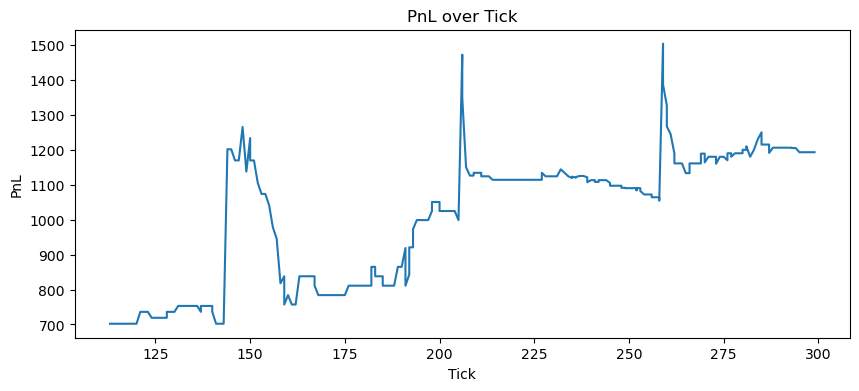

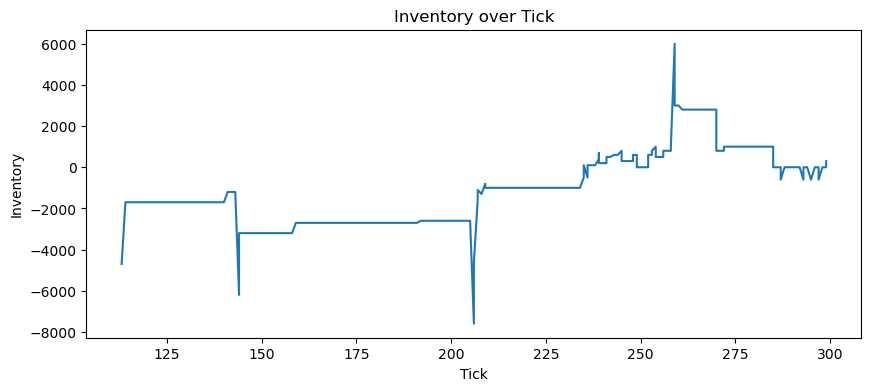

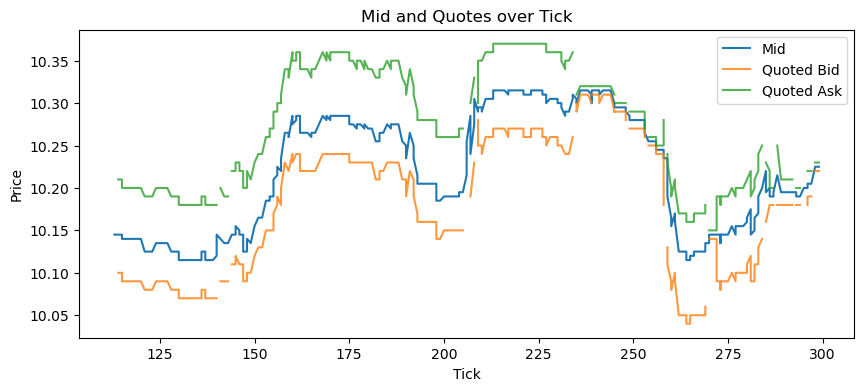

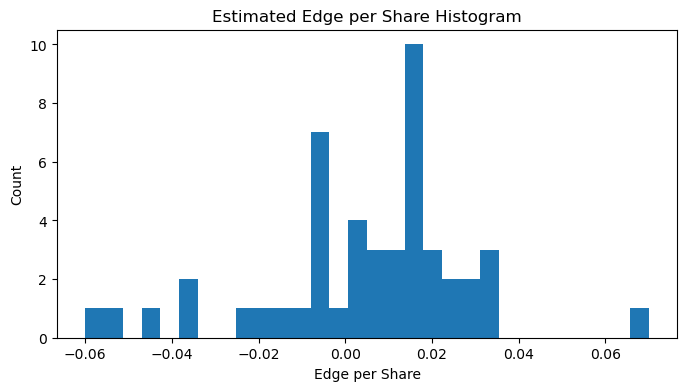

Saved: har_test_1_loop.csv, har_test_1_orders.csv, har_test_1_fills.csv


In [51]:
analyze_run(loop_df, order_df, fill_df)
save_run_logs(loop_df, order_df, fill_df, prefix='har_test_1')